In [4]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

In [5]:
data=pd.read_csv("..\Data\spam.csv", encoding="latin-1", usecols=["v1", "v2"]).rename(columns={"v1": "label", "v2": "message"})

In [6]:
import re
from html.parser import HTMLParser

# Import required libraries for text cleaning
from urllib.parse import urlparse
import string


class MLStripper(HTMLParser):
    """Helper class to strip HTML tags"""
    def __init__(self):
        super().__init__()
        self.reset()
        self.strict = False
        self.convert_charrefs = True
        self.text = []
    
    def handle_data(self, data):
        self.text.append(data)
    
    def get_data(self):
        return ''.join(self.text)

def strip_html_tags(html_text):
    """
    Remove HTML tags from text.
    
    Args:
        html_text (str): Text containing HTML tags
    
    Returns:
        str: Text with HTML tags removed
    """
    stripper = MLStripper()
    stripper.feed(html_text)
    return stripper.get_data()

def clean_text(text):
    """
    Comprehensive text cleaning function that:
    - Removes HTML tags
    - Removes URLs
    - Removes numbers
    - Converts to lowercase
    - Removes punctuation
    - Removes extra whitespaces
    
    Args:
        text (str): Raw text to clean
    
    Returns:
        str: Cleaned text
    """
    if not isinstance(text, str):
        return ""
    
    # Step 1: Remove HTML tags
    text = strip_html_tags(text)
    
    # Step 2: Remove URLs (http, https, www, etc.)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Step 3: Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    
    # Step 4: Convert to lowercase
    text = text.lower()
    
    # Step 5: Remove numbers/digits
    text = re.sub(r'\d+', '', text)
    
    # Step 6: Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Step 7: Remove extra whitespaces (multiple spaces to single space)
    text = ' '.join(text.split())
    
    # Step 8: Remove special characters
    text = re.sub(r'[^\w\s]', '', text)
    
    return text

In [7]:
data['message']=data['message'].apply(clean_text)

Tokenize and Lemmitization

In [8]:
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
nlp = spacy.load("en_core_web_sm")

In [9]:
def tokenize(column):
    doc=nlp(column)
    tokens=[]
    for token in doc:
        if token.text.lower() not in STOP_WORDS and token.is_punct==False:
            tokens.append(token.lemma_)
    return tokens
data["message"]=data["message"].apply(tokenize)


In [10]:
def remove_stopwords(columns):
    return [word for word in columns if word not in STOP_WORDS]

data["message"]=data["message"].apply(remove_stopwords)

Convert text to Vector,we start with baseline using bow

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

In [12]:
cv=CountVectorizer(lowercase=False)
X=cv.fit_transform(data["message"].apply(lambda x: ' '.join(x)))# bow accept string input not tokesnized list   
y=data["label"].map({"ham":0, "spam":1})

In [13]:
#train test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3900, 7128), (1672, 7128), (3900,), (1672,))

Model Building

Mulitnomial Naive Bayes model

In [14]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import precision_score, recall_score

#use differnt value for alpha to see the effect on accuracy

alpha=np.arange(1/100000,1, 0.1)
train_acc=[]
test_acc=[]
precision=[]
recall=[]
for a in alpha:
    model=MultinomialNB(alpha=a)
    model.fit(X_train, y_train)
    train_acc.append(model.score(X_train, y_train))
    test_acc.append(model.score(X_test, y_test))
    pred=model.predict(X_test)
    precision.append(precision_score(y_test, pred))
    recall.append(recall_score(y_test, pred))

pd.DataFrame({"alpha":alpha, "train_acc":train_acc, "test_acc":test_acc, "precision":precision, "recall":recall}).sort_values("test_acc", ascending=False).head(10)

,alpha,train_acc,test_acc,precision,recall
9,0.90001,0.988205,0.971292,0.866953,0.922374
7,0.70001,0.988718,0.970694,0.863248,0.922374
8,0.80001,0.988205,0.970694,0.863248,0.922374
6,0.60001,0.989487,0.968301,0.848739,0.922374
5,0.50001,0.989487,0.966507,0.838174,0.922374
3,0.30001,0.990513,0.962919,0.817814,0.922374
4,0.40001,0.989487,0.962919,0.817814,0.922374
0,0.00001,0.995385,0.961722,0.827004,0.894977
2,0.20001,0.991538,0.961124,0.805556,0.926941
1,0.10001,0.992308,0.960526,0.804781,0.922374


Here we are more concern about precision rather than recall evaluation metrics

In [15]:
from sklearn.metrics import ConfusionMatrixDisplay

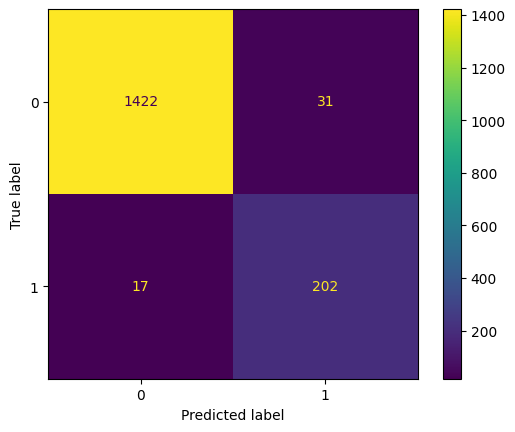

In [16]:
ConfusionMatrixDisplay.from_predictions(y_test, model.predict(X_test))

Here we missclassify 49 spam and non-spam messages

SVC Model

In [17]:
from sklearn.svm import SVC

Now we will create the fucntion to check the overall perfomance of models

In [20]:
def select_best_model(models, X_train, y_train, X_test, y_test):
    '''we will train each model and evaluate its performance on the test set, returning the best performing model based on accuracy.'''
    best_model=None
    best_score=0
    precision_scores=[]
    recall_scores=[]
    for model_name, model in models.items():
        model.fit(X_train, y_train)
        score=model.score(X_test, y_test)
        print(f"{model_name} Accuracy: {score:.4f}")
        precision=precision_score(y_test, model.predict(X_test))
        recall=recall_score(y_test, model.predict(X_test))
        precision_scores.append(precision)
        recall_scores.append(recall)
        print(f"{model_name} Precision: {precision:.4f}")
        print(f"{model_name} Recall: {recall:.4f}")
        if score>best_score:
            best_score=score
            best_model=model
    return best_model
    

In [21]:
models={
        "MultinomialNB": MultinomialNB(),
        "SVC": SVC()
    }
best_model=select_best_model(models, X_train, y_train, X_test, y_test)

MultinomialNB Accuracy: 0.9707
MultinomialNB Precision: 0.8664
MultinomialNB Recall: 0.9178
SVC Accuracy: 0.9665
SVC Precision: 0.9939
SVC Recall: 0.7489


Here we can go with SVC bt ,In model multinomial is performing better generalization then SVC ,SO better to go with multinomial

Hyperparameter Tuning on Multinomial Naive Bayes

In [22]:
from sklearn.model_selection import GridSearchCV

In [29]:
#write a fucntion to tune the hyperparameters of the best model using GridSearchCV and return the best parameters and best score
def tune_hyperparameters(model, param_grid, X_train, y_train):
    precision_scores=[]
    recall_scores=[]
    grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    grid_search .predict(X_train)
    recall_scores.append(recall_score(y_train, grid_search.predict(X_train)))
    precision_scores.append(precision_score(y_train, grid_search.predict(X_train)))
    return max(precision_scores), max(recall_scores), grid_search.best_score_,grid_search.best_params_,grid_search.best_estimator_

In [30]:
model=MultinomialNB()
param_grid = {
    'alpha': np.arctanh(np.arange(1/100000,1, 0.1))}
precision, recall, best_score, best_params, best_estimator = tune_hyperparameters(model, param_grid, X_train, y_train)
print(f"Best Parameters: {best_params}")
print(f"Best Score: {best_score:.4f}")
print(f"Best Estimator: {best_estimator}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print("Model training and hyperparameter tuning completed successfully.")

Best Parameters: {'alpha': np.float64(1.4722721236554088)}
Best Score: 0.9656
Best Estimator: MultinomialNB(alpha=np.float64(1.4722721236554088))
Precision: 0.9668
Recall: 0.9375
Model training and hyperparameter tuning completed successfully.


Here we got precision and recall much better

Final Conclusion ,go with multinomial model with alpha -->1.47

Plot Confusion metrics for multinomial naive bayes after tuning the model

In [ ]:
def plot_confusion_matrix(model, X_test, y_test):
    model=MultinomialNB(**